# Industry-Style Agentic RAG with LangGraph



## Why this is industry-style

A simple RAG system searches only the private knowledge base.

An industry-style Agentic RAG system should do this:

```text
Question
  ↓
Search private knowledge base first
  ↓
Grade the private evidence
  ↓
If private evidence is good → answer from KB
  ↓
If private evidence is weak → search the web
  ↓
Grade web evidence
  ↓
Generate a grounded answer with source type
```

This design is useful because private documents may be incomplete or outdated.

## 1. Install Dependencies

## 2. Configure API Keys

In [2]:
import os
from getpass import getpass

try:
    from dotenv import load_dotenv
    load_dotenv()
except Exception:
    pass

if not os.getenv("GROQ_API_KEY"):
    os.environ["GROQ_API_KEY"] = getpass("Enter GROQ_API_KEY: ")

if not os.getenv("TAVILY_API_KEY"):
    os.environ["TAVILY_API_KEY"] = getpass("Enter TAVILY_API_KEY: ")

if not os.getenv("PINECONE_API_KEY"):
    os.environ["PINECONE_API_KEY"] = getpass("Enter PINECONE_API_KEY: ")

print("GROQ_API_KEY configured:", bool(os.getenv("GROQ_API_KEY")))
print("TAVILY_API_KEY configured:", bool(os.getenv("TAVILY_API_KEY")))
print("PINECONE_API_KEY configured:", bool(os.getenv("PINECONE_API_KEY")))


GROQ_API_KEY configured: True
TAVILY_API_KEY configured: True
PINECONE_API_KEY configured: True


## 3. Load Real Documents

We will create our private knowledge base from a real web document:

`https://docs.langchain.com/oss/python/langgraph/agentic-rag`

This becomes our internal/private KB for the demo.

The web fallback is separate. That means:

- First source: indexed LangGraph documentation page
- Fallback source: live web search through Tavily

In [3]:
from langchain_community.document_loaders import WebBaseLoader

SOURCE_URL = "https://docs.langchain.com/oss/python/langgraph/agentic-rag"

loader = WebBaseLoader(
    web_paths=(SOURCE_URL,),
    requests_kwargs={
        "headers": {
            "User-Agent": "Mozilla/5.0 Agentic-RAG-Industry-Demo"
        }
    },
)

raw_docs = loader.load()

print("Loaded documents:", len(raw_docs))
print("Source:", raw_docs[0].metadata.get("source"))
print("\nPreview:\n")
print(raw_docs[0].page_content[:1500])

C:\Users\BAPPY\AppData\Local\Temp\ipykernel_15232\625167974.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
c:\Users\BAPPY\anaconda3\envs\project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


Loaded documents: 1
Source: https://docs.langchain.com/oss/python/langgraph/agentic-rag

Preview:

Build a custom RAG agent with LangGraph - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what's next for agents. Get your tickets →Docs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraphBuild a custom RAG agent with LangGraphOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonLearnTutorialsDeep AgentsLangChainMulti-agentLangGraphCustom RAG agentCustom SQL agentConceptual overviewsLangChain vs. LangGraph vs. Deep AgentsProviders and modelsComponent architectureMemoryContextGraph APIFunctional APIAdditional resourcesUse docs programmaticallyLangChain AcademyCa

## 4. Split the Documents into Chunks

In [4]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=150,
    add_start_index=True,
)

chunks = splitter.split_documents(raw_docs)

print("Total chunks:", len(chunks))
print("\nFirst chunk preview:\n")
print(chunks[0].page_content[:900])

Total chunks: 28

First chunk preview:

Build a custom RAG agent with LangGraph - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what's next for agents. Get your tickets →Docs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraphBuild a custom RAG agent with LangGraphOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonLearnTutorialsDeep AgentsLangChainMulti-agentLangGraphCustom RAG agentCustom SQL agentConceptual overviewsLangChain vs. LangGraph vs. Deep AgentsProviders and modelsComponent architectureMemoryContextGraph APIFunctional APIAdditional resourcesUse docs programmaticallyLangChain AcademyC


## 5. Create Free Local Embeddings


In [5]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    encode_kwargs={"normalize_embeddings": True},
)

sample_vector = embeddings.embed_query("What is Agentic RAG?")
print("Embedding dimensions:", len(sample_vector))

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3809.67it/s]


Embedding dimensions: 384


In [7]:
# sample_vector

## 6. Create the Pinecone Vector Database



The embedding model used in this notebook produces **384-dimensional vectors**, so the Pinecone index must use dimension `384`.


In [8]:
from pinecone import Pinecone, ServerlessSpec
from langchain_pinecone import PineconeVectorStore
import time

INDEX_NAME = "industry-agentic-rag-kb"
NAMESPACE = "langgraph-agentic-rag"

# Connect to Pinecone
pc = Pinecone(api_key=os.environ["PINECONE_API_KEY"])

# Create the index only if it does not already exist.
existing_indexes = [index_info["name"] for index_info in pc.list_indexes()]

if INDEX_NAME not in existing_indexes:
    pc.create_index(
        name=INDEX_NAME,
        dimension=384,       # all-MiniLM-L6-v2 embedding dimension
        metric="cosine",
        spec=ServerlessSpec(
            cloud="aws",
            region="us-east-1",
        ),
    )

    # Wait until Pinecone reports the new index as ready.
    while not pc.describe_index(INDEX_NAME).status["ready"]:
        time.sleep(1)

print("Pinecone index ready:", INDEX_NAME)

# Upload the document chunks and create the LangChain vector store.
vectorstore = PineconeVectorStore.from_documents(
    documents=chunks,
    embedding=embeddings,
    index_name=INDEX_NAME,
    namespace=NAMESPACE,
)

retriever = vectorstore.as_retriever(
    search_kwargs={
        "k": 4,
        "namespace": NAMESPACE,
    }
)

print("Pinecone vector database and retriever are ready.")


Pinecone index ready: industry-agentic-rag-kb
Pinecone vector database and retriever are ready.


In [9]:
# Load Existing Index

from pinecone import Pinecone
from langchain_pinecone import PineconeVectorStore

INDEX_NAME = "industry-agentic-rag-kb"
NAMESPACE = "langgraph-agentic-rag"

# Connect to Pinecone
pc = Pinecone(api_key=os.environ["PINECONE_API_KEY"])

# Load existing Pinecone index
index = pc.Index(INDEX_NAME)

# Connect existing index with LangChain
vectorstore = PineconeVectorStore(
    index=index,
    embedding=embeddings,
    namespace=NAMESPACE,
)

# Create retriever
retriever = vectorstore.as_retriever(
    search_kwargs={
        "k": 4,
        "namespace": NAMESPACE,
    }
)

print("Existing Pinecone index loaded:", INDEX_NAME)

Existing Pinecone index loaded: industry-agentic-rag-kb


## 7. Test Private KB Retrieval

In [10]:
test_question = "What happens if retrieved documents are not relevant in Agentic RAG?"

kb_docs = retriever.invoke(test_question)

for i, doc in enumerate(kb_docs, 1):
    print(f"\n--- KB RESULT {i} ---")
    print("Source:", doc.metadata.get("source"))
    print(doc.page_content[:700])


--- KB RESULT 1 ---
Source: https://docs.langchain.com/oss/python/langgraph/agentic-rag
docs programmaticallyLangChain AcademyCase studiesGet helpOn this pageConceptsSetupSet up LangSmithPreprocess documentsCreate a retriever toolGenerate a query or respondGrade documentsRewrite the questionGenerate an answerAssemble the graphRun the agentic RAGSee alsoTutorialsLangGraphBuild a custom RAG agent with LangGraphCopy pageCopy pageBuild a custom retrieval agent with LangGraph that decides when to search a vector store or respond directly.Copy pageCopy pageBuild a retrieval agent with LangGraph that decides when to search a vector store versus answering the user directly.

--- KB RESULT 2 ---
Source: https://docs.langchain.com/oss/python/langgraph/agentic-rag
Build a custom RAG agent with LangGraph - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is c

## 8. Initialize Groq LLM

In [11]:
from langchain_groq import ChatGroq

# Replace this model if your Groq dashboard shows a different available model.
llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
)

print(llm.invoke("Explain Agentic RAG in one sentence.").content)

Agentic RAG is a retrieval‑augmented generation approach in which an autonomous agent actively selects, prioritizes, and incorporates relevant external documents to inform and improve its generated responses.


## 9. Initialize Tavily Web Search

Tavily will be used only when the private knowledge base is insufficient.

This is important because we do not want to send every private/company question to the public web.

In [12]:
from langchain_tavily import TavilySearch

web_search = TavilySearch(
    max_results=5,
    topic="general",
    include_answer=True,
    include_raw_content=False,
)

print("Tavily search tool ready.")

Tavily search tool ready.


## 10. Define Structured Decisions

We need reliable yes/no or route outputs from the LLM.

Structured outputs help avoid parsing messy natural language.

In [13]:
from typing import List, Literal, Optional
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
from langchain_core.documents import Document


class RouteDecision(BaseModel):
    route: Literal["kb", "direct"] = Field(
        description="Use kb for questions needing Agentic RAG docs; direct for greetings/simple chat."
    )


class EvidenceGrade(BaseModel):
    grade: Literal["good", "weak"] = Field(
        description="good means evidence can answer the question; weak means not enough evidence."
    )


class AgentState(TypedDict):
    question: str
    current_query: str
    kb_docs: List[Document]
    web_results: str
    kb_grade: str
    web_grade: str
    answer: str
    source_used: str
    retry_count: int

## 11. Node 1 — Route the Question

The router decides:

- `kb`: use private knowledge base
- `direct`: answer without retrieval

In a real company assistant, this step may also route between many sources:
HR docs, finance docs, product docs, SQL database, web search, etc.

In [14]:
router_llm = llm.with_structured_output(RouteDecision, method="json_mode")

def route_question(state: AgentState):
    question = state["question"]

    decision = router_llm.invoke(f'''
You are a router for an Agentic RAG assistant.

Route to "kb" if the user asks about:
- Agentic RAG
- LangGraph Agentic RAG workflow
- retrieval grading
- query rewriting
- RAG architecture
- retriever tools
- web fallback in RAG

Route to "direct" only for greetings, thanks, or very simple conversation.

Question:
{question}

Return your response as valid JSON.
Example:
{{"route": "kb"}}
''')

    print("[Router]", decision.route)

    return {
        "current_query": question,
        "source_used": decision.route,
    }


def route_after_router(state: AgentState) -> Literal["retrieve_kb", "direct_answer"]:
    if state["source_used"] == "kb":
        return "retrieve_kb"
    return "direct_answer"

## 12. Node 2 — Retrieve from the Private KB

In [15]:
def retrieve_kb(state: AgentState):
    query = state["current_query"]
    docs = retriever.invoke(query)

    print(f"[KB Retriever] Query: {query}")
    print(f"[KB Retriever] Retrieved: {len(docs)} chunks")

    return {"kb_docs": docs}

## 13. Node 3 — Grade Private KB Evidence

This is the key step that decides whether we can answer from the private KB or need web fallback.

In [16]:
kb_grader_llm = llm.with_structured_output(EvidenceGrade, method="json_mode")

def grade_kb_evidence(state: AgentState):
    question = state["question"]

    context = "\n\n".join(
        f"Source: {doc.metadata.get('source')}\n{doc.page_content}"
        for doc in state["kb_docs"]
    )

    grade = kb_grader_llm.invoke(f'''
You are an evidence grader.

Question:
{question}

Private KB evidence:
{context}

Can this private KB evidence answer the question?
Return "good" if it can answer.
Return "weak" if it cannot answer or is incomplete.

Return your response as valid JSON.
Example:
{{"grade": "good"}}
''')

    print("[KB Grader]", grade.grade)

    return {"kb_grade": grade.grade}


def decide_after_kb_grade(state: AgentState) -> Literal["generate_from_kb", "search_web"]:
    if state["kb_grade"] == "good":
        return "generate_from_kb"
    return "search_web"

## 14. Node 4 — Tavily Web Search Fallback

This node runs only when the private KB evidence is weak.

We search the web using the original question, or the current rewritten query if a rewrite already happened.

In [17]:
def search_web(state: AgentState):
    query = state["current_query"]

    print(f"[Tavily Search] Query: {query}")

    result = web_search.invoke({"query": query})

    # Tavily can return dict/list structures depending on package version.
    # Convert it into readable text for grading and generation.
    if isinstance(result, dict):
        answer = result.get("answer", "")
        results = result.get("results", [])
        lines = []
        if answer:
            lines.append(f"Tavily answer: {answer}")

        for item in results:
            title = item.get("title", "")
            url = item.get("url", "")
            content = item.get("content", "")
            lines.append(f"Title: {title}\nURL: {url}\nContent: {content}")

        web_text = "\n\n".join(lines) if lines else str(result)
    else:
        web_text = str(result)

    print("[Tavily Search] Result characters:", len(web_text))

    return {
        "web_results": web_text,
        "source_used": "web",
    }

## 15. Node 5 — Grade Web Evidence

In [18]:
web_grader_llm = llm.with_structured_output(EvidenceGrade, method="json_mode")

def grade_web_evidence(state: AgentState):
    question = state["question"]
    web_results = state["web_results"]

    grade = web_grader_llm.invoke(f'''
You are an evidence grader.

Question:
{question}

Web search evidence:
{web_results}

Can this web evidence answer the question?
Return "good" if it can answer.
Return "weak" if it cannot answer or is incomplete.

Return your response as valid JSON.
Example:
{{"grade": "good"}}
''')

    print("[Web Grader]", grade.grade)

    return {"web_grade": grade.grade}


MAX_RETRIES = 1

def decide_after_web_grade(state: AgentState) -> Literal["generate_from_web", "rewrite_query", "answer_insufficient"]:
    if state["web_grade"] == "good":
        return "generate_from_web"

    if state["retry_count"] < MAX_RETRIES:
        return "rewrite_query"

    return "answer_insufficient"

## 16. Node 6 — Rewrite the Query

If both KB and web evidence are weak, we rewrite once and then try the KB again.

Why back to KB first?

Because the rewritten query may help retrieve better private evidence before relying on web search again.

In [19]:
from langchain_core.messages import HumanMessage

def rewrite_query(state: AgentState):
    question = state["question"]
    retry_count = state["retry_count"] + 1

    rewritten = llm.invoke(f'''
Rewrite the question for better retrieval and web search.

Rules:
- Preserve original intent.
- Make it specific and search-friendly.
- Do not answer.
- Return only the rewritten query.

Original question:
{question}
''').content.strip()

    print("[Rewriter]", rewritten)

    return {
        "current_query": rewritten,
        "retry_count": retry_count,
    }

## 17. Node 7 — Generate from Private KB

In [20]:
def generate_from_kb(state: AgentState):
    question = state["question"]

    context = "\n\n".join(
        f"[KB Source: {doc.metadata.get('source')}]\n{doc.page_content}"
        for doc in state["kb_docs"]
    )

    answer = llm.invoke(f'''
You are a technical instructor.

Answer using ONLY the private KB context.

Rules:
- Beginner-friendly explanation.
- Do not invent unsupported details.
- Mention that the answer is based on the private KB.
- Include source type: Private KB.

Question:
{question}

Private KB context:
{context}
''').content

    return {
        "answer": answer,
        "source_used": "private_kb",
    }

## 18. Node 8 — Generate from Web Search

In [21]:
def generate_from_web(state: AgentState):
    question = state["question"]
    web_context = state["web_results"]

    answer = llm.invoke(f'''
You are a technical instructor.

The private KB was insufficient, so web search was used.

Answer using ONLY the web search context.

Rules:
- Beginner-friendly explanation.
- Do not invent unsupported details.
- Mention that the answer is based on Tavily web search.
- Include source type: Web Search.
- If URLs are present in context, include the most useful URLs.

Question:
{question}

Web search context:
{web_context}
''').content

    return {
        "answer": answer,
        "source_used": "web_search",
    }

## 19. Node 9 — Direct Answer

In [22]:
def direct_answer(state: AgentState):
    question = state["question"]

    answer = llm.invoke(f'''
Respond briefly and naturally.

Message:
{question}
''').content

    return {
        "answer": answer,
        "source_used": "direct",
    }

## 20. Node 10 — Insufficient Evidence Answer

In [23]:
def answer_insufficient(state: AgentState):
    answer = (
        "I could not find enough reliable evidence in the private knowledge base "
        "or the web search results to answer this confidently. "
        "Please provide more specific documents or rephrase the question."
    )

    return {
        "answer": answer,
        "source_used": "insufficient_evidence",
    }

## 21. Build the LangGraph Workflow



In [24]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(AgentState)

workflow.add_node("route_question", route_question)
workflow.add_node("retrieve_kb", retrieve_kb)
workflow.add_node("grade_kb_evidence", grade_kb_evidence)
workflow.add_node("search_web", search_web)
workflow.add_node("grade_web_evidence", grade_web_evidence)
workflow.add_node("rewrite_query", rewrite_query)
workflow.add_node("generate_from_kb", generate_from_kb)
workflow.add_node("generate_from_web", generate_from_web)
workflow.add_node("direct_answer", direct_answer)
workflow.add_node("answer_insufficient", answer_insufficient)

workflow.add_edge(START, "route_question")

workflow.add_conditional_edges(
    "route_question",
    route_after_router,
    {
        "retrieve_kb": "retrieve_kb",
        "direct_answer": "direct_answer",
    },
)

workflow.add_edge("retrieve_kb", "grade_kb_evidence")

workflow.add_conditional_edges(
    "grade_kb_evidence",
    decide_after_kb_grade,
    {
        "generate_from_kb": "generate_from_kb",
        "search_web": "search_web",
    },
)

workflow.add_edge("search_web", "grade_web_evidence")

workflow.add_conditional_edges(
    "grade_web_evidence",
    decide_after_web_grade,
    {
        "generate_from_web": "generate_from_web",
        "rewrite_query": "rewrite_query",
        "answer_insufficient": "answer_insufficient",
    },
)

workflow.add_edge("rewrite_query", "retrieve_kb")
workflow.add_edge("generate_from_kb", END)
workflow.add_edge("generate_from_web", END)
workflow.add_edge("direct_answer", END)
workflow.add_edge("answer_insufficient", END)

app = workflow.compile()

print("Industry-style Agentic RAG graph compiled.")

Industry-style Agentic RAG graph compiled.


## 22. Visualize the Graph

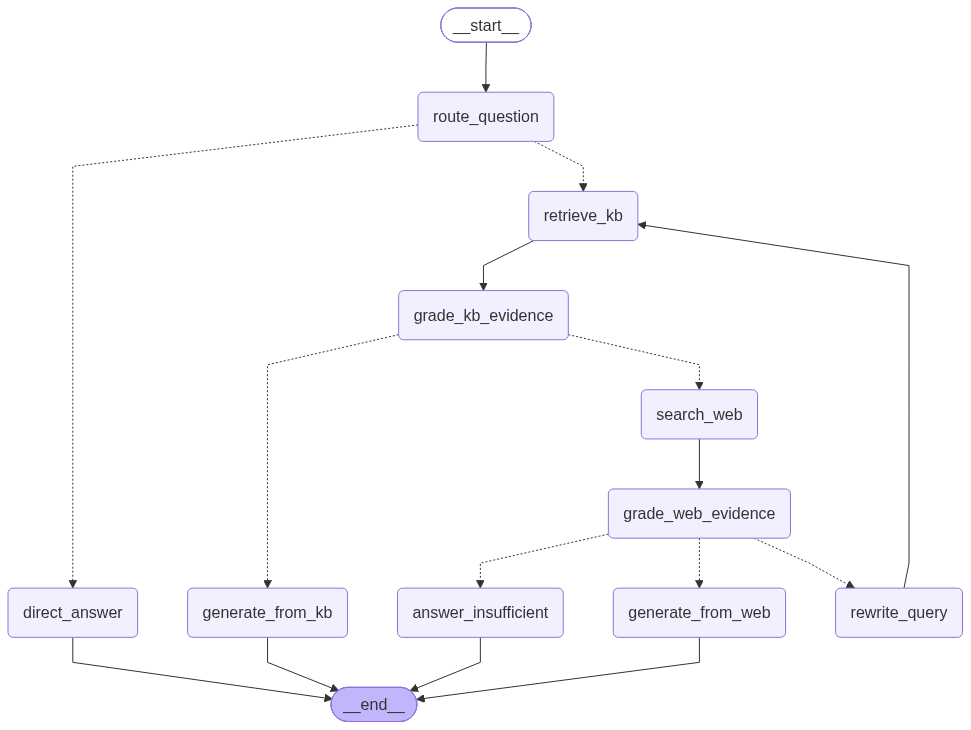

In [25]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization is optional. The graph can still run.")
    print("Reason:", e)

## 23. Helper Function

In [26]:
def ask_agent(question: str):
    initial_state: AgentState = {
        "question": question,
        "current_query": question,
        "kb_docs": [],
        "web_results": "",
        "kb_grade": "",
        "web_grade": "",
        "answer": "",
        "source_used": "",
        "retry_count": 0,
    }

    result = app.invoke(initial_state)

    print("\n" + "=" * 90)
    print("QUESTION:")
    print(question)
    print("\nSOURCE USED:")
    print(result["source_used"])
    print("\nFINAL ANSWER:")
    print(result["answer"])
    print("=" * 90)

    return result

## 24. Demo 1 — Answer from Private KB

In [27]:
result = ask_agent(
    "In Agentic RAG, what happens when retrieved documents are not relevant?"
)

[Router] kb
[KB Retriever] Query: In Agentic RAG, what happens when retrieved documents are not relevant?
[KB Retriever] Retrieved: 4 chunks
[KB Grader] weak
[Tavily Search] Query: In Agentic RAG, what happens when retrieved documents are not relevant?
[Tavily Search] Result characters: 7599
[Web Grader] good

QUESTION:
In Agentic RAG, what happens when retrieved documents are not relevant?

SOURCE USED:
web_search

FINAL ANSWER:
**Answer (based on a Tavily web search)**  

In Agentic Retrieval‑Augmented Generation (Agentic RAG), the system first checks whether the documents it pulled from its knowledge base actually help answer the user’s question. If the retrieved documents are judged to be **not relevant** (or not good enough), the agent does not just use them anyway. Instead, it:

1. **Triggers a new search** – the agent initiates a web search or uses another retrieval method to find better‑matching information.  
2. **May refuse or ask for clarification** – if it still can’t find 

## 25. Demo 2 — Web Search Fallback

In [28]:
result = ask_agent(
    "What is Tavily Search and why is it useful for AI agents and RAG workflows?"
)

[Router] kb
[KB Retriever] Query: What is Tavily Search and why is it useful for AI agents and RAG workflows?
[KB Retriever] Retrieved: 4 chunks
[KB Grader] weak
[Tavily Search] Query: What is Tavily Search and why is it useful for AI agents and RAG workflows?
[Tavily Search] Result characters: 5938
[Web Grader] good

QUESTION:
What is Tavily Search and why is it useful for AI agents and RAG workflows?

SOURCE USED:
web_search

FINAL ANSWER:
**What is Tavily Search?**  
Tavily is a *search API* that is built specifically for AI agents and retrieval‑augmented generation (RAG) pipelines. Instead of giving a list of links for a human to click, it returns short, ranked, information‑dense snippets that a large language model (LLM) can read and reason over directly. It also lets developers extract clean content from a URL, crawl an entire site, or generate a research report from a single query—all in real‑time.

**Why is it useful for AI agents and RAG workflows?**  
- **Real‑time, up‑to‑dat

## 26. Demo 3 — Direct Answer

In [29]:
result = ask_agent("Hello, how are you?")

[Router] direct

QUESTION:
Hello, how are you?

SOURCE USED:
direct

FINAL ANSWER:
Hi! I'm doing well, thanks. How about you?


## 27. Demo 4 — Ask a Current / External Question

In [30]:
result = ask_agent(
    "What is the current LangChain Tavily package used for Python web search integration?"
)

[Router] kb
[KB Retriever] Query: What is the current LangChain Tavily package used for Python web search integration?
[KB Retriever] Retrieved: 4 chunks
[KB Grader] weak
[Tavily Search] Query: What is the current LangChain Tavily package used for Python web search integration?
[Tavily Search] Result characters: 6555
[Web Grader] good

QUESTION:
What is the current LangChain Tavily package used for Python web search integration?

SOURCE USED:
web_search

FINAL ANSWER:
**Answer (based on a Tavily web search)**  

The current LangChain package that lets you add real‑time web search to a Python application is called **`langchain‑tavily`**.  
It is the official LangChain integration with Tavily and gives you a set of ready‑made tools:

| Tool | What it does | Import path |
|------|--------------|-------------|
| `TavilySearch` | Performs a web search and returns concise summaries, URLs, snippets, and optional images | `from langchain_tavily import TavilySearch` |
| `TavilyExtract` | Pulls 

## 28. Why This Is More Industry-Ready

This implementation has:

1. **Private KB first** — trusted source first.
2. **Evidence grading** — do not trust weak retrieval.
3. **Web fallback** — use Tavily when KB is insufficient.
4. **Query rewriting** — recover from weak search.
5. **Retry guard** — avoid infinite loops.
6. **Source tracking** — know whether answer came from KB, web or direct path.
7. **LangGraph control flow** — stateful, visible and debuggable workflow.